<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_csc161_mod1_OR_%26_NAND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**


CSC 161; Deep Learning;
January 25, 2026.

**INSTRUCTIONS**



**OVERVIEW:**
In this assignment, you will:

**Part 1:** Build a simple perceptron for a linearly separable problem—specifically, the logical OR function.

**Part 2:** Develop a multi-layer neural network (with one hidden layer) to learn the NAND function, providing hands-on practice with forward propagation and backpropagation.

*Throughout the assignment, you will work with Google Colab, Python and NumPy to implement weights, biases, activation functions, and the backpropagation learning algorithm from scratch. This exercise reinforces historical neural network ideas and provides practical experience with two different logical functions.

**Review:**

If needed, review the following lectures:

Video - Introduction to Google Colab: https://youtu.be/uLzetacTRVs
Video - Python Coding Lecture Activity: Building Neural Networks from Scratch: https://youtu.be/nfhu0_tGpgs




**PART 1: Implementing a Simple Perceptron for the OR Function**

**A. Theoretical Background:**


Recall that the perceptron, introduced by Frank Rosenblatt in 1958, was one of the earliest neural network models. It adjusts its weights using a simple update rule to handle linearly separable data. In this example, you will simulate a perceptron that learns the OR function.

**B. Instructions:**

1. Create the dataset for the OR function:

a) Inputs: [[0,0], [0,1], [1,0], [1,1]];

b) Expected Output: [0, 1, 1, 1];

2. Initialize the weights and bias with small random numbers.

3. Implement the step activation function.

4. Train the perceptron using the update rule.

5. Visualize the decision boundary and print predictions after training.

**CODE/PROGRAMMING:**

**PART 1**

Load the necessary librarys/packages.

In [131]:
import numpy as np
import matplotlib.pyplot as plt


**Define the OR dataset** (input and expected output). 0 represents False, and 1 represents True.

In [132]:
#Input
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

The OR truth table.

In [133]:
#Expected Output for "OR" gate
Y = np.array([0,1,1,1])   #false, true, true, true. *(does not meet the threshold, meets the threshold, meets the threshold, meets the threshold)

Perpectron Parameters (OR gate).

In [134]:
learning_rate = 0.1

In [135]:
#Number of Epochs is 20
 #(but could do different iterations with more than 20, just to see what happens with the decreasing loss over epochs depending on how many epochs there are.
n_epochs = 20

Initialize Weights and Bias (for 2 input features).

In [136]:
#small random numbers
weights = np.random.randn(2)
bias = np.random.randn()

Use the Activation Function (Step Function).

The step function is used because it is sort of like a biological situation of a neuron firing - it either fires or it doesn't. The action potential either reaches the cutoff threhold to fire, or it doesn't fire at all if the action potential is anywhere below the threshold. This is a single layer network that has linearly separable data (it either passes the threshold cutoff or it doesn't, with both OR and AND gates).

In [137]:
def step_function(x):
  return 1 if x >= 0 else 0

Training the Perceptron (OR gate).

In [138]:
for epoch in range(n_epochs):
  for i in range (len(X)):

    #Calculate linear combination
    linear_output = np.dot(X[i], weights) + bias
    prediction = step_function(linear_output)

    #Calculate error
    error = Y[i] - prediction

    #Update weights and bias if there is an error
    weights += learning_rate * error * X[i]
    bias += learning_rate * error

Print Epoch information (with Weights and Bias for each - OR gate).

We can see that the weights were 0.1548 to 0.1088 (rounded) and the bias was -0.0612 (rounded).

In [139]:
#Print epoch info
print(f'Epoch {epoch+1}/{n_epochs}) - Weights: {weights}, Bias: {bias}')

Epoch 20/20) - Weights: [0.15477473 0.10884842], Bias: -0.06118269205747856


Testing the Perceptron. Print the Final Predictions. (OR gate).

Here, the predicted and expected were the same, so the performance was perfect for our OR gate single layer perceptron. We got 0,1,1,1 or false,true,true,true.

In [140]:
print("\nFinal Predictions:")
for i in range(len(X)):
  pred = step_function(np.dot(X[i], weights) + bias)
  print(f"Input: {X[i]}, Predicted: {pred}, Expected: {Y[i]}")


Final Predictions:
Input: [0 0], Predicted: 0, Expected: 0
Input: [0 1], Predicted: 1, Expected: 1
Input: [1 0], Predicted: 1, Expected: 1
Input: [1 1], Predicted: 1, Expected: 1


Visualize the Decision Boundary / Create the Figure (OR gate).

For a single-layer perceptron, the decision boundary is always linear, meaning it is always a line, with:  w₁x + w₂y + b = 0.


In [141]:
#Create a grid of values
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))

#Compute the decision boundary line: weights[0]*x + weights[1]*y + bias = 0
boundary = -(weights[0] * xx + bias) / weights[1]

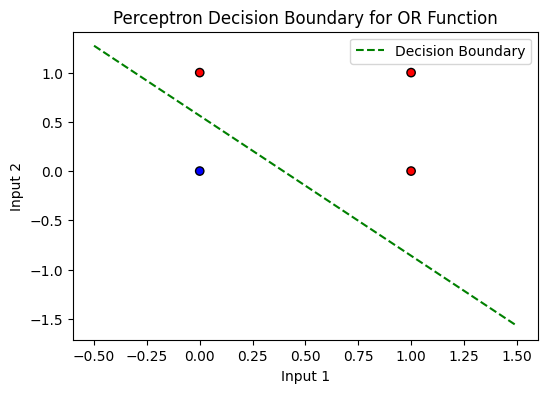

In [143]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=Y, cmap='bwr', edgecolors='k')
plt.plot(xx[0,:], boundary[0,:], "g--", label='Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title("Perceptron Decision Boundary for OR Function")
plt.legend()
plt.show()

If you look at the Figure above (that visualizes the decision boundary for OR gate), you can see that the blue point falls below the decision boundary (it fell below the threshold to "fire" the action potential so to speak, and the 3 red points fall above the decision boundary for the OR decision gate, meaning they "fired". Blue dots correspond with OR = 0, and red dots correspond with OR = 1. In our results above, we had 0,1,1,1, (for both predicted and expected) which correspond with blue, red, red, red on the figure.

**END Part 1. //**

**PART 2: Building a Multi-Layer Neural Network for the NAND Function**

**A. Theoretical Background:**

Although NAND is linearly separable and can be solved by a single-layer perceptron, this part is designed to provide practice with multi-layer network design—including forward propagation and backpropagation. The NAND function outputs 0 only when all inputs are 1; otherwise, it outputs 1.

**B. Instructions:**

1. Create the NAND dataset:

a) Inputs: [[0,0], [0,1], [1,0], [1,1]]

b) Expected Output: [1, 1, 1, 0]

2. Initialize weights and biases for a two-layer network (input to hidden and hidden to output).

3. Use the sigmoid activation function for both layers.

4. Implement forward propagation, compute the loss (Mean Squared Error), and perform backpropagation.

5. Train the network for a specified number of epochs (e.g., 10,000) and print the loss periodically.

6. Test the network on the NAND dataset and compare predictions to expected values.

**CODE/PROGRAMMING**

**PART 2**

Import necessary libraries/packages.

In [144]:
import numpy as np

Define the NAND dataset.

In [145]:
X_and = np.array([[0,0],
                 [0,1],
                 [1,0],
                 [1,1]])

Define the outputs. Outputs for AND are 1,1,1,0 which is true,true,true,false;  (whereas for OR, they were 0,0,0,1).

In [146]:
Y_and = np.array([[1],
                 [1],
                 [1],
                 [0]])

Activation Function: Sigmoid and it's Derivative (AND gate).

In [147]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
  return x * (1-x)

Network Architecture Parameters (AND gate).

a) Dimentions for input, output, and hidden layers (AND gate).

In [149]:
#Input, Output, and Hidden dimensions
input_dim = 2
hidden_dim = 2 #Using 2 hidden neurons
output_dim = 1



b) Define the learning rate and number of epochs (AND gate).

In [150]:
#Learning Rate
learning_rate = 0.5

#number of epochs is 10000
n_epochs = 10000

Initialize Weights and Biases (AND gate).

In [151]:
#Weights for input to hidden layer
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))

#Weights for hidden to output layer
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))

Training the Network. Print each Epoch and its Loss (AND gate).

In [152]:
for epoch in range(n_epochs):
  #Forward Pass
  #Hidden Layer
  Z1 = np.dot(X_and, W1) + b1
  A1 = sigmoid(Z1)

  #Output Layer
  Z2 = np.dot(A1, W2) + b2
  A2 = sigmoid(Z2)

  #Compute Loss (Mean Squared Error)
  loss = np.mean((Y_and - A2) ** 2)

  #Backpropagation
  #Compute Error at Output Layer
  dA2 = -2 * (Y_and - A2)
  dZ2 = dA2 * sigmoid_derivative(A2) # Corrected: using A2
  dW2 = np.dot(A1.T, dZ2)
  db2 = np.sum(dZ2, axis=0, keepdims=True)

  #Error Propagated to Hidden Layer
  dA1 = np.dot(dZ2, W2.T)
  dZ1 = dA1 * sigmoid_derivative(A1) # Corrected: using A1
  dW1 = np.dot(X_and.T, dZ1)
  db1 = np.sum(dZ1, axis=0, keepdims=True)

  #Update Weights and Biases
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2
  W1 -= learning_rate * dW1
  b1 -= learning_rate * db1

  #Optionally print loss every 1000 epochs.
  if (epoch + 1) % 1000 == 0:
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss}")

Epoch 1000/10000, Loss: 0.0009436930527084127
Epoch 2000/10000, Loss: 0.0003719076165077476
Epoch 3000/10000, Loss: 0.0002255831477289921
Epoch 4000/10000, Loss: 0.0001602722905494642
Epoch 5000/10000, Loss: 0.00012364743953422526
Epoch 6000/10000, Loss: 0.00010033609354573794
Epoch 7000/10000, Loss: 8.424779633864712e-05
Epoch 8000/10000, Loss: 7.25014827005074e-05
Epoch 9000/10000, Loss: 6.356235371874353e-05
Epoch 10000/10000, Loss: 5.65396914763987e-05


When you see the epoch results for the AND gate multi-layer network printed (above), you can see that the earlier epochs had greater/larger loss values, and these loss values got smaller and smaller with each epoch, until the last epoch has the smallest loss value. That means the model is getting fewer and fewer things wrong over time as the number of epochs increases.

For the first epoch (1000/10,000) the loss was 0.0009437 (rounded). The last epoch (10,000/10,000) had a loss of 0.0000565 (rounded), which is exponentially smaller than the loss for the first one.

Print the results that says "Training Complete".

In [153]:
print("\nTraining Complete.\n")



Training Complete.



Testing the Network on the NAND dataset.

Because the losses above are pretty small, the results should be perfect or close to perfect (with a small dataset and small losses), in this multi-layer AND gate network. We can see that the predicted values are very close to the expected values for three cases and the same as the expected value in one case. When rounding, 0.993 round to 1, and 0.012 round to 0, and 1.0 is 1.

In [157]:
print ("Predictions for AND:")
for i in range(len(X_and)):
  #Forward pass for each sample
  a1_test = sigmoid(np.dot(X_and[i], W1) + b1)
  a2_test = sigmoid(np.dot(a1_test, W2) + b2)
  print(f"Input: {X_and[i]}, Predicted: {np.round(a2_test[0], 3)}, Expected: {Y_and[i][0]}")

Predictions for AND:
Input: [0 0], Predicted: [1.], Expected: 1
Input: [0 1], Predicted: [0.993], Expected: 1
Input: [1 0], Predicted: [0.993], Expected: 1
Input: [1 1], Predicted: [0.012], Expected: 0


For a multilayer network and the AND gate for decisions, we expect to get 1,1,1,0 which corresponds to true, true, true, false.

The expected outputs was 1, 1, 1, 0, and that's what we got. The predicted matches this. The predicted for the input [0,0] was 1.0, so the Expected was 1. The predicted for the input [0,1] was 0.993, so the Expected was 1 (with 0.993 being close to 1). The predicted for the input [1,0] was 0.993, so the Expected was 1. Lastly, the predicted for the input [1,1] was 0.012 so the Expected was 0 (with 0.012 being close to 0).  We got perfect performance.

**Note:** The first time I rean this, I got all 0.5's for the predicted values, which alerted to me that there was likely an error. Why could I get a predicted of 0.5 that yielded an expected of 0, but also get a predicted of 0.5 that yielded an expected of 1? I research it and found out it meant that the model wasn't learning, because something was wrong. It was just averaging everything. It could have been the activation function wasn't working, or the learning rate was too high, or something else. I discovered I had typed in the mean squared error incorrectly and left off the 2. Once I corrected this, I saw the losses decreasing faster, and I got predicted values that were not all 0.5 for each one, which meant that the network was learning.

Visualize the AND gate multi-layer network's decision boundary.

I tried to do this and it was a lot harder than I thought, mainly because the boundary is not a line, and the graph is not linear, for a multi-layer network.

This is harder to do than the OR-gate single-layer perceptron network (not because of the OR-gate but because it had only a single layer, regardless of if the boundary decision was OR or AND). With more than a single-layer (in this case hidden layer so hence multi-layer network, regardless of if the decision gate is OR or AND), the boundary is not linear, hence not a "line". It would likely have curves in the boundary, or a "bent line" or a corner/box-like region, or something that looks irregular. The equation for a multi-layer network is not linear as it was for the single-layer perceptron. It could have piece-wise linear or curved boundaries, with an equation for the boundary being something like: σ( w₂ · σ(w₁x + b₁) + b₂ ).


**END of coding sections. //**

**Submission Instructions:**

**1. File Format:**

1a) Your assignment must be submitted as a Jupyter Notebook file (.ipynb) which can be downloaded from Google Colab.

**2. File Naming:**

2a) Name your file using your last name (for example, “Smith.ipynb”).

**3. Components:**

3a) Include both Part 1 (perceptron for the OR function) and Part 2 (multi-layer network for the NAND function) in your notebook.

3b) Add comments and explanations in your code for clarity.

**4. Submission Method:**

4a) Submit your notebook file via Brightspace

**END. //** Thank you very much.